# 📊 Financial Data — Cleaning & Exploratory Data Analysis

**Dataset:** Financials Dataset (Kaggle)  
**Tools:** Python, pandas, matplotlib  
**By:** Bukunmi Damilola Olokede

---

## 📌 Objective
Practice end-to-end data cleaning and EDA on a raw financial dataset exported from Excel/Power BI.

**Cleaning tasks:**
- Audit and fix column name errors
- Remove `$`, `,` and `-` from numeric columns
- Cast object columns to float
- Parse date column to datetime

**EDA tasks:**
- Missing value analysis
- Categorical exploration
- Descriptive statistics
- Sales & Profit timeline visualisation

## 1️⃣ Import Libraries

I import `pandas` for data manipulation and `matplotlib` for visualisation.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## 2️⃣ Load Data

I Load the raw CSV and take a first look at its shape and contents.

In [3]:
df=pd.read_csv(r'C:\Users\DELL\Desktop\research\Financials.csv')
print(df.shape)
df.head(3)

(700, 16)


,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014


## 3️⃣ Audit Column Names
Before touching any data, we inspect column names using `repr()` to expose hidden whitespace — a common issue with Excel/Power BI exports.

In [10]:
for col in df.columns:
    print(repr(col))

'segment'
'country'
'product'
'discount_band'
'units_sold'
'manufacturing_price'
'sale_price'
'gross_sales'
'discounts'
'sales'
'cogs'
'profit'
'date'
'month_number'
'month_name'
'year'


## 4️⃣ Fix Column Names

Strip leading/trailing spaces, collapse double spaces, and convert to `snake_case` for clean, professional column references.

In [11]:
df.columns = df.columns.str.strip()
df.columns = [col.replace('  ', ' ') for col in df.columns]
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(df.columns.tolist())

['segment', 'country', 'product', 'discount_band', 'units_sold', 'manufacturing_price', 'sale_price', 'gross_sales', 'discounts', 'sales', 'cogs', 'profit', 'date', 'month_number', 'month_name', 'year']


## 5️⃣ Clean Numeric Columns

All 8 financial columns were stored as strings containing `$` signs, thousands commas, and bare `-` representing zero.  
We strip all three and cast to `float64`.

In [12]:
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

print("Done — cell values are cleaned")

Done — cell values are cleaned


In [18]:
numeric_cols = [
    'units_sold', 'manufacturing_price', 'sale_price',
    'gross_sales', 'discounts', 'sales', 'cogs', 'profit'
]

In [19]:
print(df['discounts'].unique()[:10])
print(df['profit'].unique()[:10])

['$-' '$276.15' '$344.40' '$72.10' '$44.73' '$92.82' '$222.96' '$4,235.00'
 '$177.03' '$173.40']
['$16,185.00' '$13,210.00' '$10,890.00' '$4,440.00' '$12,350.00'
 '$1,36,170.00' '$4,605.00' '$22,662.00' '$18,990.00' '$13,905.00']


In [20]:
def clean_numeric(series):
    s = series.astype(str).str.strip()   # ensure it's a string
    s = s.str.replace('$', '', regex=False)   # remove dollar sign
    s = s.str.replace(',', '', regex=False)   # remove commas (the challenge!)
    s = s.str.strip()                         # strip any leftover whitespace
    s = s.replace('-', '0')                   # bare dash = zero
    return pd.to_numeric(s, errors='coerce')  # cast to float

In [21]:
for col in numeric_cols:
    df[col] = clean_numeric(df[col])

print(df[numeric_cols].dtypes)

units_sold             float64
manufacturing_price    float64
sale_price             float64
gross_sales            float64
discounts              float64
sales                  float64
cogs                   float64
profit                 float64
dtype: object


## 6️⃣ Parse Date Column
Convert the `date` column from string to `datetime64` using `dayfirst=True` to correctly handle DD/MM/YYYY format.  
We also create a `yearmonth` period column for monthly aggregation.

In [29]:
print(df['date'].dtype)
print(df['date'].head(5))

object
0    01/01/2014
1    01/01/2014
2    01/06/2014
3    01/06/2014
4    01/06/2014
Name: date, dtype: object


In [31]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print(df['date'].dtype)
print(df['date'].head(5))


datetime64[ns]
0   2014-01-01
1   2014-01-01
2   2014-06-01
3   2014-06-01
4   2014-06-01
Name: date, dtype: datetime64[ns]


In [32]:
df['yearmonth'] = df['date'].dt.to_period('M')

print(df['yearmonth'].head(5))

0    2014-01
1    2014-01
2    2014-06
3    2014-06
4    2014-06
Name: yearmonth, dtype: period[M]


In [19]:
print(df.dtypes)
print(f"\nShape: {df.shape}")

segment                        object
country                        object
product                        object
discount band                  object
units sold                    float64
manufacturing price           float64
sale price                    float64
gross sales                   float64
discounts                     float64
sales                         float64
cogs                          float64
profit                        float64
date                   datetime64[ns]
month number                    int64
month name                     object
year                            int64
yearmonth                   period[M]
dtype: object

Shape: (700, 17)


## 7️⃣ Missing Value Analysis

Check every column for nulls before drawing any conclusions.

In [24]:
print(df.isnull().sum())

segment                 0
country                 0
product                 0
discount_band           0
units_sold              0
manufacturing_price     0
sale_price              0
gross_sales             0
discounts               0
sales                   0
cogs                    0
profit                 58
date                    0
month_number            0
month_name              0
year                    0
dtype: int64


## 8️⃣ Categorical EDA

Explore the unique values across all categorical columns to understand the universe of the dataset.

In [33]:
cat_cols = ['segment', 'country', 'product', 'discount_band']

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique → {df[col].unique().tolist()}")
    

segment: 5 unique → ['Government', 'Midmarket', 'Channel Partners', 'Enterprise', 'Small Business']
country: 5 unique → ['Canada', 'Germany', 'France', 'Mexico', 'United States of America']
product: 6 unique → ['Carretera', 'Montana', 'Paseo', 'Velo', 'VTT', 'Amarilla']
discount_band: 4 unique → ['None', 'Low', 'Medium', 'High']


## 9️⃣ Descriptive Statistics

Summarise the distribution of key numeric columns.  
Pay attention to the gap between `mean` and `median` — it reveals skewness in the data.

In [34]:
print(df[['units_sold', 'sales', 'profit', 'discounts']].describe().round(2))

       units_sold       sales     profit  discounts
count      700.00      700.00     642.00     700.00
mean      1608.29   169609.07   27524.96   13150.35
std        867.43   236726.35   42960.44   22962.93
min        200.00     1655.08       0.00       0.00
25%        905.00    15928.00    3635.37     800.32
50%       1542.50    35540.20   10890.00    2585.25
75%       2229.12   261077.50   25061.40   15956.35
max       4492.50  1159200.00  262200.00  149677.50


## 🔟 Top Performers

Identify which segments and products drive the most sales and profit.

In [35]:
print("Top segment by sales:")
print(df.groupby('segment')['sales'].sum().sort_values(ascending=False))

print("\nTop product by profit:")
print(df.groupby('product')['profit'].sum().sort_values(ascending=False))

Top segment by sales:
segment
Government          52504260.68
Small Business      42427918.50
Enterprise          19611694.38
Midmarket            2381883.09
Channel Partners     1800593.64
Name: sales, dtype: float64

Top product by profit:
product
Paseo        4917986.71
VTT          3156348.02
Amarilla     2936044.07
Velo         2431448.72
Montana      2171281.13
Carretera    2057914.89
Name: profit, dtype: float64


In [36]:
print("Top product by sales:")
print(df.groupby('product')['sales'].sum().sort_values(ascending=False))

print("\nTop product by profit margin %:")
product_stats = df.groupby('product').agg(sales=('sales','sum'), profit=('profit','sum'))
product_stats['margin%'] = (product_stats['profit'] / product_stats['sales'] * 100).round(1)
print(product_stats['margin%'].sort_values(ascending=False))



Top product by sales:
product
Paseo        33011143.96
VTT          20511921.02
Velo         18250059.47
Amarilla     17747116.07
Montana      15390801.88
Carretera    13815307.89
Name: sales, dtype: float64

Top product by profit margin %:
product
Amarilla     16.5
VTT          15.4
Carretera    14.9
Paseo        14.9
Montana      14.1
Velo         13.3
Name: margin%, dtype: float64


## 1️⃣1️⃣ Sales & Profit Over Time

Visualise monthly sales and profit on a dual-axis chart to identify trends, seasonality and anomalies.

In [38]:
monthly = df.groupby('yearmonth')[['sales', 'profit']].sum().reset_index()
monthly['yearmonth_dt'] = monthly['yearmonth'].dt.to_timestamp()

print(monthly.head())

  yearmonth       sales      profit yearmonth_dt
0   2013-09  4484000.03   812564.28   2013-09-01
1   2013-10  9295611.10  1659555.10   2013-10-01
2   2013-11  7267203.30   840631.05   2013-11-01
3   2013-12  5368441.08   788051.58   2013-12-01
4   2014-01  6607761.69   874544.94   2014-01-01


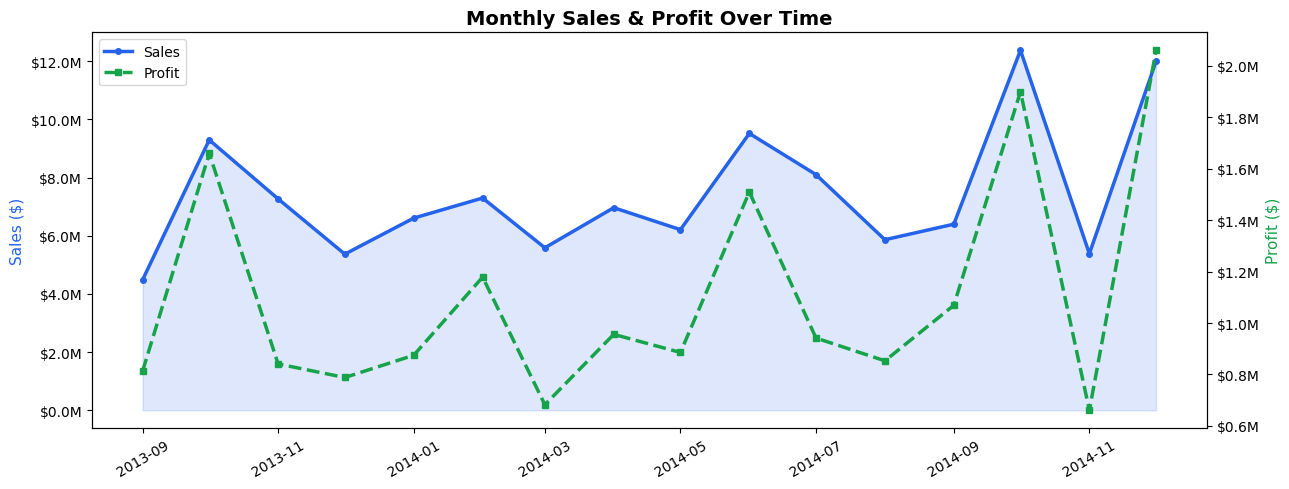

<Figure size 640x480 with 0 Axes>

In [44]:
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['yearmonth_dt'], monthly['sales'], alpha=0.15, color='#2563EB')
ax1.plot(monthly['yearmonth_dt'], monthly['sales'], color='#2563EB', linewidth=2.5, marker='o', markersize=4, label='Sales')
ax2.plot(monthly['yearmonth_dt'], monthly['profit'], color='#16A34A', linewidth=2.5, marker='s', markersize=4, linestyle='--', label='Profit')

ax1.set_ylabel('Sales ($)', color='#2563EB', fontsize=11)
ax2.set_ylabel('Profit ($)', color='#16A34A', fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.tick_params(axis='x', rotation=30)

plt.title('Monthly Sales & Profit Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.savefig('sales_profit_timeline.png', bbox_inches='tight', dpi=150)

## 1️⃣2️⃣ Sales & Profit by Segment

Which customer segment drives the most revenue?  
The dark overlay shows profit alongside sales — revealing which segments are both high volume and high margin.

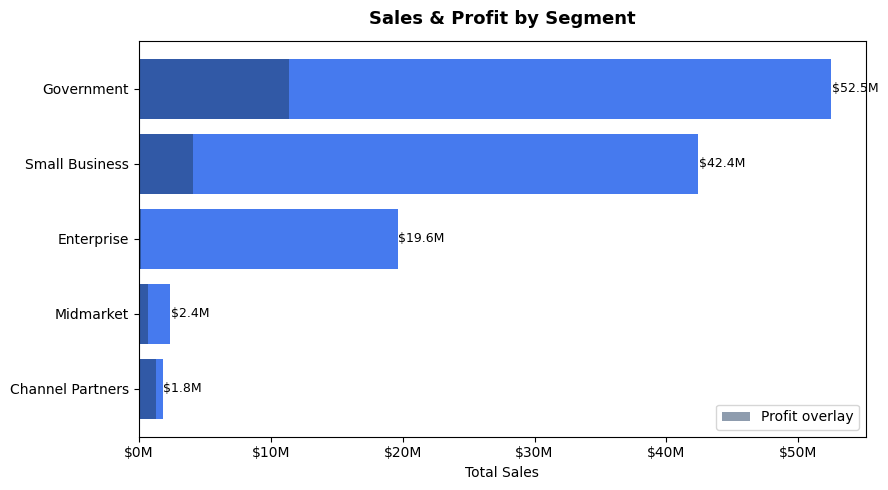

In [40]:
seg_data = df.groupby('segment')[['sales','profit']].sum().sort_values('sales', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(seg_data.index, seg_data['sales'], color='#2563EB', alpha=0.85)
ax.barh(seg_data.index, seg_data['profit'], color='#1e3a5f', alpha=0.5, label='Profit overlay')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

for bar, val in zip(bars, seg_data['sales']):
    ax.text(val + 50000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=9)

ax.set_title('Sales & Profit by Segment', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Sales')
ax.legend()
plt.tight_layout()
plt.show()

## 1️⃣3️⃣ Total Profit by Product

Which products make the most money?  
Bars are coloured green for profit and red for loss, making performance instantly readable.

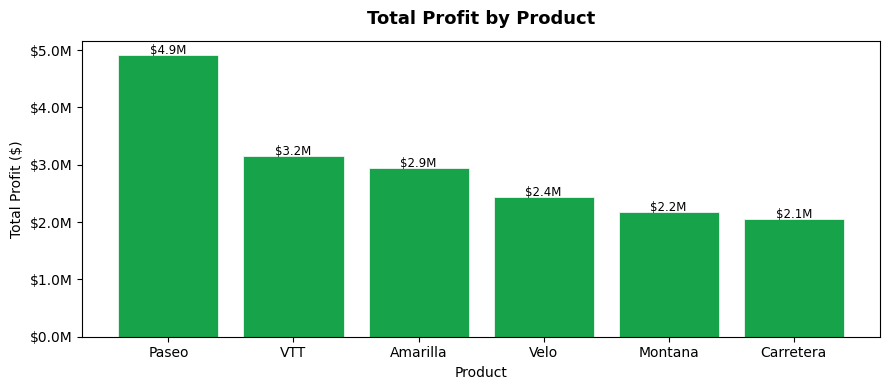

In [41]:
prod_profit = df.groupby('product')['profit'].sum().sort_values(ascending=False)
colors = ['#16A34A' if v > 0 else '#DC2626' for v in prod_profit]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(prod_profit.index, prod_profit.values, color=colors, edgecolor='white', linewidth=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Total Profit by Product', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Product')
ax.set_ylabel('Total Profit ($)')

for i, (prod, val) in enumerate(prod_profit.items()):
    ax.text(i, val + 20000, f'${val/1e6:.1f}M', ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

## 1️⃣4️⃣ Profit Margin % by Country

Sales volume alone is misleading. A country can have high sales but terrible margins.  
This chart reveals which markets are truly efficient, not just busy.

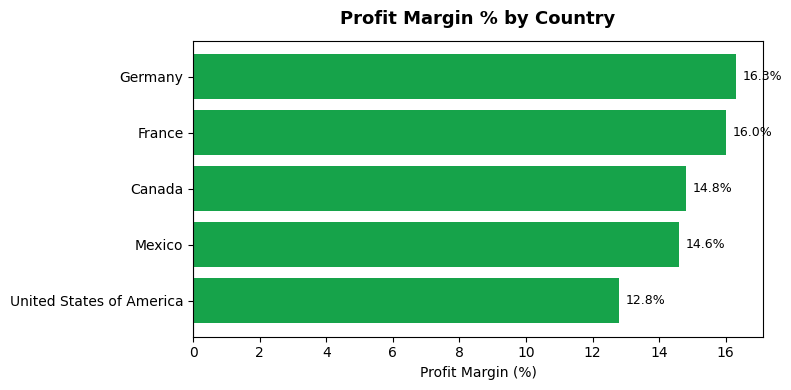

In [42]:
ctry = df.groupby('country').agg(sales=('sales','sum'), profit=('profit','sum'))
ctry['margin%'] = (ctry['profit'] / ctry['sales'] * 100).round(1)
ctry = ctry.sort_values('margin%', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(ctry.index, ctry['margin%'],
        color=['#16A34A' if v > 0 else '#DC2626' for v in ctry['margin%']])
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Profit Margin (%)')
ax.set_title('Profit Margin % by Country', fontsize=13, fontweight='bold', pad=12)

for bar, val in zip(ax.patches, ctry['margin%']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 1️⃣5️⃣ Average Profit by Discount Band

How much does discounting hurt profitability?  
A clear downward trend from None → High confirms that aggressive discounting significantly erodes margins.

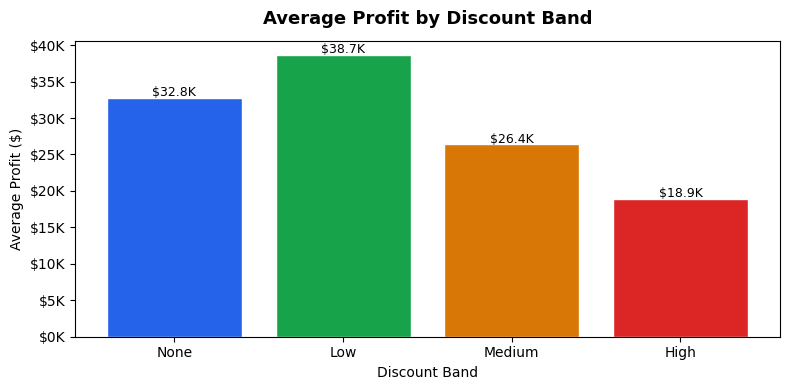

In [43]:
disc_order = ['None', 'Low', 'Medium', 'High']
avg_profit = (df[df['discount_band'].isin(disc_order)]
              .groupby('discount_band')['profit']
              .mean()
              .reindex(disc_order))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg_profit.index, avg_profit.values,
              color=['#2563EB','#16A34A','#D97706','#DC2626'],
              edgecolor='white')
ax.set_title('Average Profit by Discount Band', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Discount Band')
ax.set_ylabel('Average Profit ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

for i, val in enumerate(avg_profit):
    ax.text(i, val + 200, f'${val/1e3:.1f}K', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 🔍 Key Insights

1. **Government dominates** — $52.5M in sales, nearly 3x second place Small Business

2. **Paseo is the star product** — highest cumulative profit at $4.9M across all 6 products

3. **Channel Partners & Midmarket are negligible** — combined under $4M, business is heavily government-dependent

4. **USA leads in sales volume** — largest country by total revenue

5. **Discounts consistently kill profit** — average profit drops sharply from None → High discount band

6. **Q4 seasonal spikes** — visible in both 2013 and 2014, likely government year-end budget cycles

7. **November 2014 anomaly** — sales peaked at $12M but profit crashed to $0.6M, suggesting extreme discounting or a cost 
spike worth investigating

8. **58 missing profit values** — only data quality issue found, worth investigating upstream

---
*Analysis by: Bukunmi Damilola Olokede | Tools: Python, pandas, matplotlib | Dataset:Financials Dataset from Kaggle*